In [2]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("drugbank_with_descriptors.csv", sep="\t")
df

,ID1,ID2,Y,Map,X1,X2,MolWt_X1,LogP_X1,NumHDonors_X1,NumHAcceptors_X1,TPSA_X1,MolWt_X2,LogP_X2,NumHDonors_X2,NumHAcceptors_X2,TPSA_X2
0,DB04571,DB00460,1,#Drug1 may increase the photosensitizing activ...,CC1=CC2=CC3=C(OC(=O)C=C3C)C(C)=C2O1,COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...,228.247,3.46446,0,3,43.35,718.807,6.71924,3,9,173.56
1,DB00855,DB00460,1,#Drug1 may increase the photosensitizing activ...,NCC(=O)CCC(O)=O,COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...,131.131,-0.62100,2,3,80.39,718.807,6.71924,3,9,173.56
2,DB09536,DB00460,1,#Drug1 may increase the photosensitizing activ...,O=[Ti]=O,COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...,79.865,-0.24010,0,2,34.14,718.807,6.71924,3,9,173.56
3,DB01600,DB00460,1,#Drug1 may increase the photosensitizing activ...,CC(C(O)=O)C1=CC=C(S1)C(=O)C1=CC=CC=C1,COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...,260.314,3.16720,1,3,54.37,718.807,6.71924,3,9,173.56
4,DB09000,DB00460,1,#Drug1 may increase the photosensitizing activ...,CC(CN(C)C)CN1C2=CC=CC=C2SC2=C1C=C(C=C2)C#N,COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...,323.465,4.35868,0,4,30.27,718.807,6.71924,3,9,173.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191793,DB00437,DB00492,86,The risk of a hypersensitivity reaction to #Dr...,OC1=NC=NC2=C1C=NN2,CCC(=O)O[C@@H](O[P@](=O)(CCCCC1=CC=CC=C1)CC(=O...,136.114,0.05850,2,4,74.69,563.672,6.12130,1,6,110.21
191794,DB00437,DB09477,86,The risk of a hypersensitivity reaction to #Dr...,OC1=NC=NC2=C1C=NN2,[H][C@@](C)(N[C@@]([H])(CCC1=CC=CC=C1)C(O)=O)C...,136.114,0.05850,2,4,74.69,348.399,1.12610,3,4,106.94
191795,DB00437,DB00790,86,The risk of a hypersensitivity reaction to #Dr...,OC1=NC=NC2=C1C=NN2,[H][C@]12C[C@H](N(C(=O)[C@H](C)N[C@@H](CCC)C(=...,136.114,0.05850,2,4,74.69,368.474,1.94060,2,5,95.94
191796,DB00415,DB00437,86,The risk of a hypersensitivity reaction to #Dr...,[H][C@]12SC(C)(C)[C@@H](N1C(=O)[C@H]2NC(=O)[C@...,OC1=NC=NC2=C1C=NN2,349.412,0.31810,3,5,112.73,136.114,0.05850,2,4,74.69


In [6]:
print(df.head())  
print(df.info())  
print(df.columns) 

       ID1      ID2  Y                                                Map  \
0  DB04571  DB00460  1  #Drug1 may increase the photosensitizing activ...   
1  DB00855  DB00460  1  #Drug1 may increase the photosensitizing activ...   
2  DB09536  DB00460  1  #Drug1 may increase the photosensitizing activ...   
3  DB01600  DB00460  1  #Drug1 may increase the photosensitizing activ...   
4  DB09000  DB00460  1  #Drug1 may increase the photosensitizing activ...   

                                           X1  \
0         CC1=CC2=CC3=C(OC(=O)C=C3C)C(C)=C2O1   
1                             NCC(=O)CCC(O)=O   
2                                    O=[Ti]=O   
3       CC(C(O)=O)C1=CC=C(S1)C(=O)C1=CC=CC=C1   
4  CC(CN(C)C)CN1C2=CC=CC=C2SC2=C1C=C(C=C2)C#N   

                                                  X2  MolWt_X1  LogP_X1  \
0  COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...   228.247  3.46446   
1  COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...   131.131 -0.62100   
2  COC(=O)CCC1=C2

In [8]:
print(df.isnull().sum())

df = df.drop_duplicates()
print("Duplicates removed. New shape:", df.shape)

ID1                 0
ID2                 0
Y                   0
Map                 0
X1                  0
X2                  0
MolWt_X1            0
LogP_X1             0
NumHDonors_X1       0
NumHAcceptors_X1    0
TPSA_X1             0
MolWt_X2            0
LogP_X2             0
NumHDonors_X2       0
NumHAcceptors_X2    0
TPSA_X2             0
dtype: int64
Duplicates removed. New shape: (191798, 16)


Class distribution:
 Y
49    60748
47    34360
73    23779
75     9470
60     8397
      ...  
28       11
52       10
1        10
26        7
42        6
Name: count, Length: 86, dtype: int64


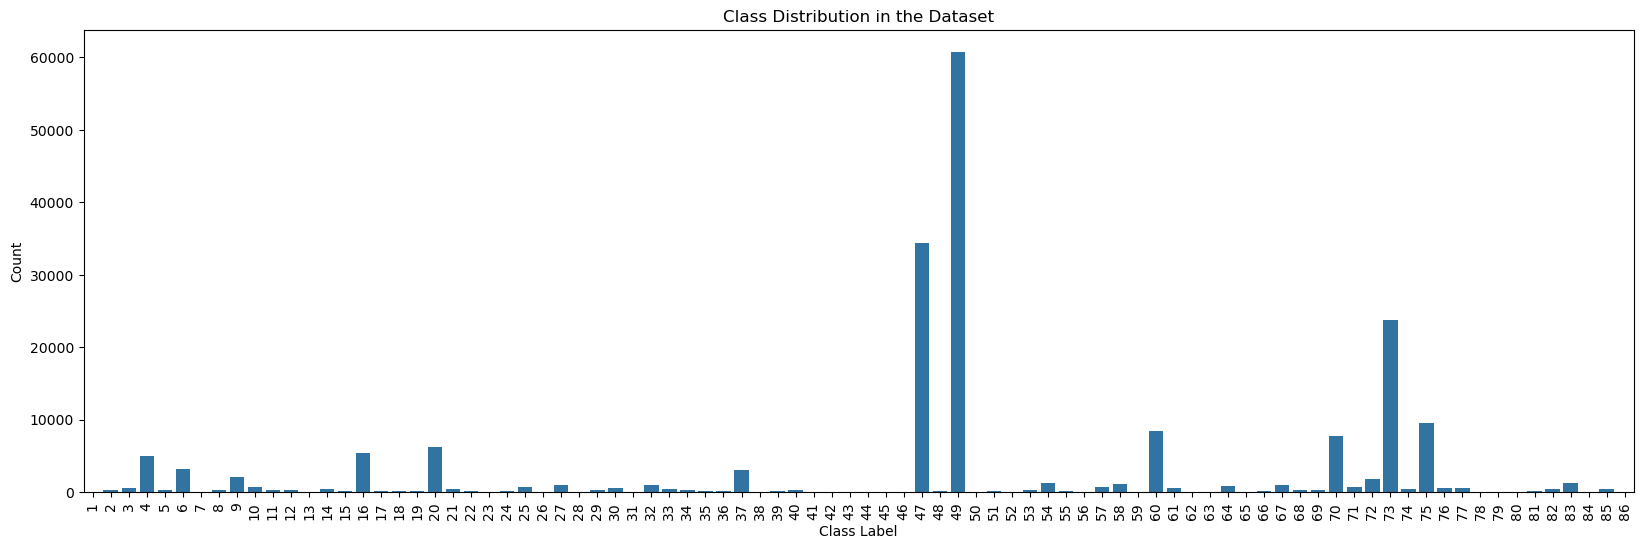

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of observations in each class
class_counts = df['Y'].value_counts()
print("Class distribution:\n", class_counts)

# Plot class distribution
plt.figure(figsize=(20, 6))  # Increase width for better visibility
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.title("Class Distribution in the Dataset")
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.show()

In [12]:
df = df[["Y", "MolWt_X1", "LogP_X1", "NumHDonors_X1", "NumHAcceptors_X1", "TPSA_X1",
         "MolWt_X2", "LogP_X2", "NumHDonors_X2", "NumHAcceptors_X2", "TPSA_X2"]]

In [14]:
undersample_threshold = 20000  # Adjust based on your needs
oversample_threshold = 15000    # Minimum samples desired per class

In [16]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler


# Undersampling: Reduce large classes
majority_classes = class_counts[class_counts > undersample_threshold].index
undersampler = RandomUnderSampler(sampling_strategy={cls: undersample_threshold for cls in majority_classes}, random_state=42)
X_under, y_under = undersampler.fit_resample(df.drop(columns=["Y"]), df["Y"])
df_balanced = pd.DataFrame(X_under, columns=df.drop(columns=["Y"]).columns)
df_balanced["Y"] = y_under

In [18]:
# Oversampling: Boost small classes
minority_classes = class_counts[class_counts < oversample_threshold].index
oversampler = RandomOverSampler(sampling_strategy={cls: oversample_threshold for cls in minority_classes}, random_state=42)
X_over, y_over = oversampler.fit_resample(df_balanced.drop(columns=["Y"]), df_balanced["Y"])
df_balanced = pd.DataFrame(X_over, columns=df_balanced.drop(columns=["Y"]).columns)
df_balanced["Y"] = y_over

In [20]:
new_class_counts = df_balanced["Y"].value_counts()
print("New Class Distribution:\n", new_class_counts)

New Class Distribution:
 Y
47    20000
49    20000
73    20000
1     15000
56    15000
      ...  
28    15000
27    15000
26    15000
25    15000
86    15000
Name: count, Length: 86, dtype: int64


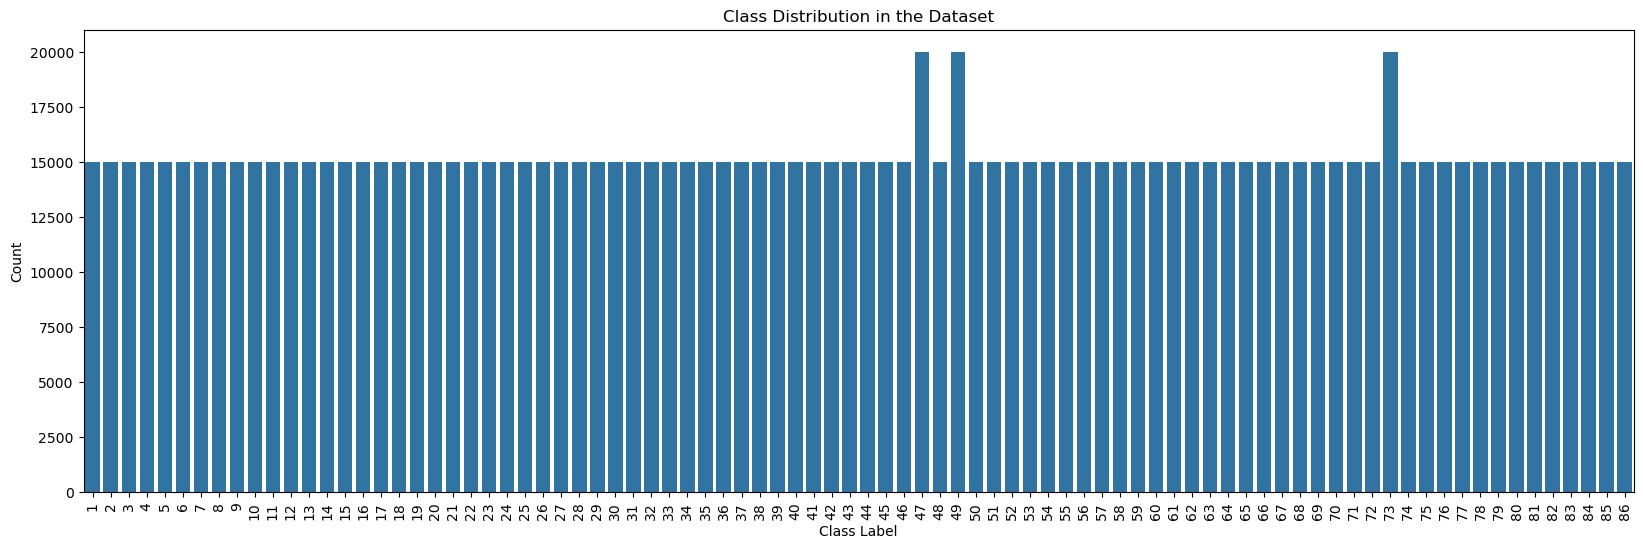

In [22]:
plt.figure(figsize=(20, 6))  # Increase width for better visibility
sns.barplot(x=class_counts.index, y=new_class_counts.values)
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.title("Class Distribution in the Dataset")
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.show()

In [24]:
# Save balanced dataset
df_balanced.to_csv("balanced_dataset.csv", index=False)

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [30]:
file_path = "balanced_dataset.csv"
df = pd.read_csv(file_path)

In [32]:
# Split features (X) and target (Y)
X = df.drop(columns=["Y"])
y = df["Y"]

In [34]:
# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [42]:
from tqdm import tqdm  # Progress bar
import time

In [44]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)

# Start Timer
start_time = time.time()

# Track Progress Manually
print("Training Random Forest...\n")
for i in tqdm(range(1, rf_model.n_estimators + 1), desc="Fitting Progress", unit="trees"):
    rf_model.set_params(n_estimators=i)  # Incrementally fit trees
    rf_model.fit(X_train, y_train)

# End Timer
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nTraining Completed in {elapsed_time:.2f} seconds.")


Training Random Forest...



Fitting Progress: 100%|██████████████████████| 200/200 [3:24:43<00:00, 61.42s/trees]


Training Completed in 12283.54 seconds.


In [48]:
import joblib

# Save the trained model
model_filename = "random_forest_model_with_sampling.pkl"
joblib.dump(rf_model, model_filename)
print(f"Model saved as {model_filename}")

Model saved as random_forest_model_with_sampling.pkl


In [50]:
y_pred = rf_model.predict(X_test)

In [52]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")


Accuracy: 0.8259


In [54]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00      3000
           2       0.75      0.77      0.76      3000
           3       0.96      1.00      0.98      3000
           4       0.63      0.70      0.66      3000
           5       0.84      0.93      0.88      3000
           6       0.80      0.52      0.63      3000
           7       1.00      0.95      0.98      3000
           8       0.97      0.94      0.96      3000
           9       0.75      0.46      0.57      3000
          10       0.77      0.71      0.74      3000
          11       0.88      0.65      0.75      3000
          12       0.81      0.74      0.77      3000
          13       0.99      1.00      0.99      3000
          14       0.66      0.92      0.77      3000
          15       0.93      1.00      0.96      3000
          16       0.81      0.51      0.62      3000
          17       0.96      0.99      0.98      3000
  

In [56]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", conf_matrix)


Confusion Matrix:
 [[3000    0    0 ...    0    0    0]
 [   0 2307    0 ...   62    0    0]
 [   0    0 2994 ...    0    0    0]
 ...
 [   0    0    0 ... 2953    0    0]
 [   0   16    0 ...   26 2672    0]
 [   0    0    0 ...    0    0 3000]]


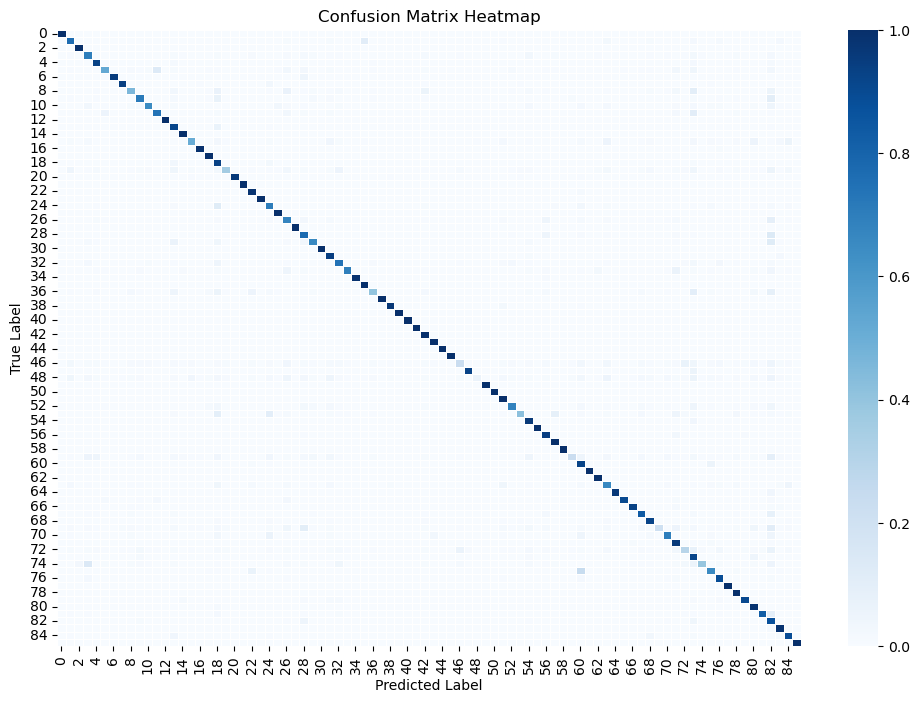

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Normalize confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred, normalize="true")

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=False, cmap="Blues", linewidths=0.5)

# Labels and Title
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

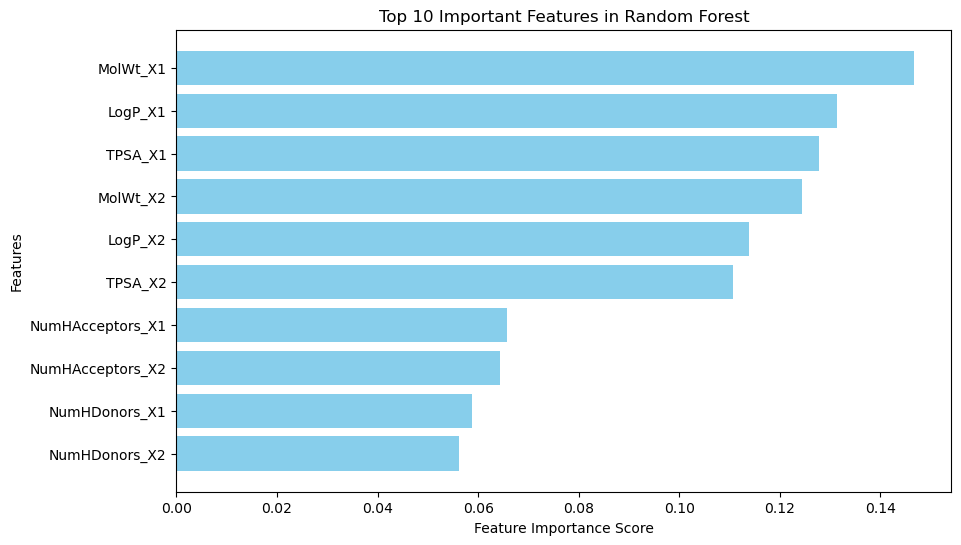

In [62]:
import numpy as np

# Get feature importance scores
feature_importances = rf_model.feature_importances_
features = X_train.columns

# Sort by importance
sorted_idx = np.argsort(feature_importances)[::-1]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(features[sorted_idx][:10], feature_importances[sorted_idx][:10], color="skyblue")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Important Features in Random Forest")
plt.gca().invert_yaxis()
plt.show()

In [70]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Binarize the labels for multi-class ROC-AUC
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
y_pred_proba = rf_model.predict_proba(X_test)  # Get probability estimates

# Compute ROC-AUC score (One-vs-Rest)
roc_auc = roc_auc_score(y_test_binarized, y_pred_proba, average="macro", multi_class="ovr")

print(f"Multi-Class ROC-AUC Score: {roc_auc:.4f}")

Multi-Class ROC-AUC Score: 0.9932


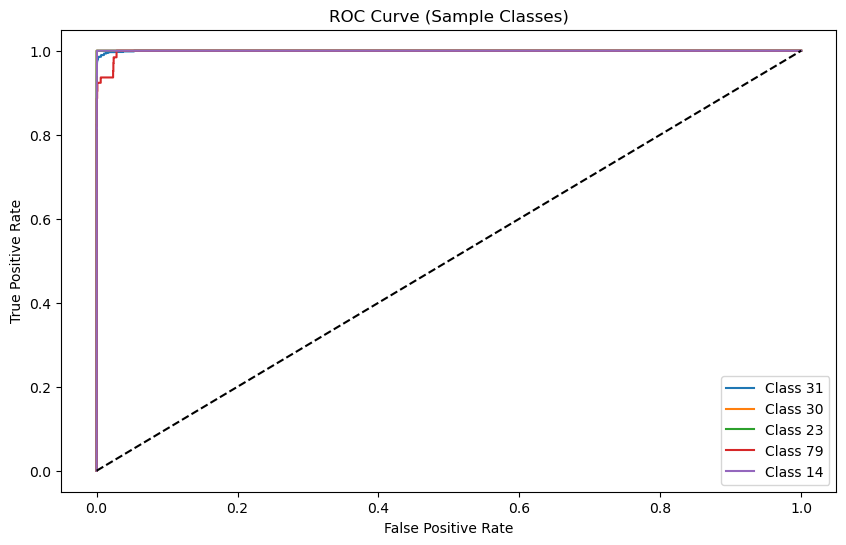

In [72]:
from sklearn.metrics import roc_curve
import random

# Select a few random classes to visualize
random_classes = random.sample(list(np.unique(y_test)), 5)  # Pick 5 random classes
plt.figure(figsize=(10, 6))

for class_id in random_classes:
    fpr, tpr, _ = roc_curve(y_test_binarized[:, class_id], y_pred_proba[:, class_id])
    plt.plot(fpr, tpr, label=f"Class {class_id}")

# Plot settings
plt.plot([0, 1], [0, 1], "k--")  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Sample Classes)")
plt.legend()
plt.show()